# Proyecto 2.1. Generador de lenguaje mediante RNN

## Objetivo general

Desarrollar modelos de lenguaje secuencial utilizando redes recurrentes tipo LSTM en Keras para predecir el siguiente carácter o la siguiente palabra en una secuencia de texto, comparar el desempeño entre distintas arquitecturas recurrentes y documentar el proceso completo: preparación de datos, entrenamiento, generación de texto y evaluación (incluyendo una métrica de calidad como la perplejidad).

## Descripción
Se construirán dos versiones del problema, usando un corpus propio:

1. Modelo de lenguaje a nivel carácter (char-level language model): dado un string de longitud fija (por ejemplo 40 caracteres), predecir el siguiente carácter.

2. Modelo de lenguaje a nivel de palabra (word-level language model): dada una secuencia de n palabras (por ejemplo 10 palabras), predecir la siguiente palabra.

En cada versión (carácter y palabra) se deben entrenar CUATRO arquitecturas de RNN, todas en Keras:

Arquitecturas obligatorias

Modelo 1. Embedding → LSTM → Dense

Modelo 2. Embedding → LSTM → Dropout → Dense

Modelo 3. Embedding → Stacked LSTM (2 capas LSTM) → Dropout → Dense.

Importante: la primera LSTM debe tener return_sequences=True para apilar la segunda.

Modelo 4. Embedding → Bidirectional(LSTM) → Dropout → Dense


### Creación de modelos
En las arquitecturas de los modelos, se tienen los siguientes hiperparámetros:

* Tamaño del embedding (EMBEDDING_DIM): 50
* Unidades LSTM (LSTM_UNITS): 128
* Tasa de dropout (DROPOUT_RATE): 0.2 (esto solo aplica para los modelos 2 al 4).
* Función de pérdida (sparse_categorical_crossentropy): La literatura recomienda usar esta función debido a que las salidas que se requieren predecir son enteros simples.
* Optimizador: adam
* Número de épocas de entrenamiento: 10
* Tamaño del lote: 128



In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
import os

vocab_size = 54
longitud_secuencia = 40
EMBEDDING_DIM = 50
LSTM_UNITS = 128
DROPOUT_RATE = 0.2

Para el modelo 1, la arquitectura es la siguiente:

Modelo 1. Embedding → LSTM → Dense

* Embedding(input_dim=$54$, output_dim=$50$)\
* LSTM(units=$128$)\
* Dense(units=$54$, activation='softmax')

In [ ]:
def create_model_1(v_size, e_dim, s_len, l_units):
    model = Sequential()
    model.add(Embedding(input_dim=v_size, output_dim=e_dim, input_length=s_len))
    model.add(LSTM(units=l_units))
    model.add(Dense(units=v_size, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print("\nModelo 1:\n")
model_1 = create_model_1(vocab_size, EMBEDDING_DIM, longitud_secuencia, LSTM_UNITS)
model_1.summary()


Modelo 1:



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Para el modelo 2 se tiene la siguiente arquitectura:

Modelo 2. Embedding → LSTM → Dropout → Dense

Embedding(input_dim=$54$, output_dim=$50$)\
LSTM(units=$128$)\
Dropout(rate=$0.2$)\
Dense(units=$54$, activation='softmax')

In [ ]:
def create_model_2(v_size, e_dim, s_len, l_units, d_rate):
    model = Sequential()
    model.add(Embedding(input_dim=v_size, output_dim=e_dim, input_length=s_len))
    model.add(LSTM(units=l_units))
    model.add(Dropout(d_rate))
    model.add(Dense(units=v_size, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print("\nModelo 2:\n")
model_2 = create_model_2(vocab_size, EMBEDDING_DIM, longitud_secuencia, LSTM_UNITS, DROPOUT_RATE)
model_2.summary()


Modelo 2:



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

El tercer modelo sigue la siguiente arquitectura:

Modelo 3. Embedding → Stacked LSTM (2 capas LSTM) → Dropout → Dense. (Recordando que la primera LSTM debe tener return_sequences=True para apilar la segunda.)

Embedding(input_dim=$54$, output_dim=$50$)\
LSTM(units=$128$, return_sequences=True)\
LSTM(units=$128$)\
Dropout(rate=$0.2$)\
Dense(units=$54$, activation='softmax')


Generalmente una capa LSTM normal realiza el procesamiento de una secuencia de entrada y el resultado es un solo vector de salida. Si se requiere recibir una secuencia completa de entrada en una segunda capa esta no es un solo vector como en una LSTM normal. En este contexto, en la primer capa LSTM se hace uso de return_sequences = True para que devuelva el vector de salida en cada uno de los pasos de tiempo en lugar de únicamente el final.

In [ ]:
def create_model_3(v_size, e_dim, s_len, l_units, d_rate):
    model = Sequential()
    model.add(Embedding(input_dim=v_size, output_dim=e_dim, input_length=s_len))
    model.add(LSTM(units=l_units, return_sequences=True))
    model.add(LSTM(units=l_units))
    model.add(Dropout(d_rate))
    model.add(Dense(units=v_size, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print("\nModelo 3:\n")
model_3 = create_model_3(vocab_size, EMBEDDING_DIM, longitud_secuencia, LSTM_UNITS, DROPOUT_RATE)
model_3.summary()


Modelo 3:



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Finalmente la última red consiste de la siguiente arquitectura:

Modelo 4. Embedding → Bidirectional(LSTM) → Dropout → Dense

Embedding(input_dim=$54$, output_dim=$50$) \
Bidirectional(LSTM(units=$128$)) \
Dropout(rate=$0.2$) \
Dense(units=$54$, activation='softmax')

En general una capa LSTM básica solo procesa la secuencia de izquierda a derecha, por lo que el contexto únicamente se basa en el contexto anteriormente visto. Cuando se genera una capa bidireccional LSTM, esta procesa la información primeramente de forma normal (de izquierda a derecha) y posteriormente realiza el procesamiento de forma inversa (de derecha a izquierda). Esto permite que el modelo aprenda tanto el pasado como el futuro en las secuencias, lo que la hace más robusta ante predicciones.

In [ ]:
def create_model_4(v_size, e_dim, s_len, l_units, d_rate):
    model = Sequential()
    model.add(Embedding(input_dim=v_size, output_dim=e_dim, input_length=s_len))
    model.add(Bidirectional(LSTM(units=l_units)))
    model.add(Dropout(d_rate))
    model.add(Dense(units=v_size, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print("\nModelo 4:\n")
model_4 = create_model_4(vocab_size, EMBEDDING_DIM, longitud_secuencia, LSTM_UNITS, DROPOUT_RATE)
model_4.summary()


Modelo 4:



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

De igual forma, para mostrar las gráficas y perpléxity se hace uso de una función.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def graficar(history, model_name):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(loss) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs_range, loss, 'bo-', label='Pérdida de Entrenamiento')
    plt.plot(epochs_range, val_loss, 'ro-', label='Pérdida de Validación')
    plt.title(f'Curvas de Entrenamiento - {model_name}')
    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.grid(True)
    plt.show()

def calculo_metricas(model, history, model_name, X_test_data, y_test_data):
    print(f"Métricas({model_name})\n\n")

    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]

    print(f"Pérdida final de Loss: {final_train_loss:.4f}")
    print(f"Pérdida final de Val_Loss: {final_val_loss:.4f}")

    perplexity_val = np.exp(final_val_loss)
    print(f"\n Perplexity en Validación: {perplexity_val:.4f}\n\n")


    test_loss, test_accuracy = model.evaluate(X_test_data, y_test_data, verbose=0)

    print(f"Pérdida final en Test_Loss: {test_loss:.4f}")

    perplexity_test = np.exp(test_loss)
    print(f"Perplexity en Test: {perplexity_test:.4f}\n\n")

    return final_train_loss, final_val_loss, perplexity_val, test_loss, perplexity_test

## 1. Descripción del corpus
El corpus a utilizar se basa en una historia popular que habla acerca de la historia de la música.

* Título: "A Popular History of the Art of Music: From the Earliest Times Until the Present" (Una Historia Popular del Arte de la Música: Desde los Tiempos Más Antiguos Hasta el Presente).

* Autor: W. S. B. (William Smythe Babcock) Mathews (1837-1912).

* Fuente: Project Gutenberg (eBook #20293).

* Idioma: Inglés.

* Licencia: Dominio Público en los Estados Unidos (Copyright Status: Public domain in the USA).

* Créditos de Digitalización: E-text preparado por Juliet Sutherland, Linda Cantoni, y el Project Gutenberg Online Distributed Proofreading Team.

In [ ]:
import re

def analizar_corpus(file_path='gutenberg_music.txt'):
    with open(file_path, 'r', encoding='utf-8') as f:
        raw_text = f.read()

    total_caracteres = len(raw_text)

    total_palabras = len(raw_text.split())

    print(f"Tamaño total en caracteres: {total_caracteres:,}")
    print(f"Tamaño total en palabras:    {total_palabras:,}")

    print("\n" + "="*50 + "\n")

    print("Ejemplos de Texto Bruto: "+'\n'*2)

    print("Ejemplo 1: ")
    print(raw_text[0:450])


    inicio_ejemplo = raw_text.find("PREFACE.")
    if inicio_ejemplo != -1:
        print("\n\nEjemplo 2:")
        print(raw_text[inicio_ejemplo : inicio_ejemplo + 450])

    inicio_ejemplo_i = raw_text.find("CHAPTER I.")
    if inicio_ejemplo_i != -1:
        inicio_contenido = raw_text.find("By a curious fortune", inicio_ejemplo_i)
        if inicio_contenido != -1:
            print("\n\nEjemplo 3: ")
            print(raw_text[inicio_contenido : inicio_contenido + 450])

analizar_corpus()

Tamaño total en caracteres: 769,253
Tamaño total en palabras:    127,063


Ejemplos de Texto Bruto: 


Ejemplo 1: 
The Project Gutenberg eBook of A Popular History of the Art of Music
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this ebook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the 


Ejemplo 2:
PREFACE.


I have here endeavored to provide a readable account of the entire
history of the art of music, within the compass of a single small
volume, and to treat the luxuriant and many-sided later development
with the particularity proportionate to its importance, and the
greater interest appertaining to it from its proximity to the times of
the reader.

The range of the work can be most easily estimated from the T

Para el proceso de preprocesamiento, se pretende convertir todas las palabras en minúsculas. De igual manera, el texto abarca únicamente desde donde comienza 'INTRODUCTION.' hasta antes de encontrar la palabra 'INDEX.'. También hay algunos elementos intermedios que aparecen con frecuencia los cuales pueden ser eliminados con expresiones regulares, tal como '[Illustration]' , '[Music illustration: DECIPHERING OF ABOVE]', etc. Además de eso también se eliminarán las citas de autores y encabezados como 'Book First', 'CHAPTER I.', etc. Se mantienen los signos de puntuación estándar y los saltos de línea simples se remplazan simplemente por un espacio mientras que los dobles (o mas) saltos de linea se remplazan únicamente por un salto de línea.

Este preprocesamiento se realizó de esta manera para evitar que el modelo no aprenda de igual manera el contexto, ya que al querer realizar predicción es importante tener en consideración esto. Los números como tal también son importantes (en algunos casos) tal como el año que se creó una canción o nació un artista. Frases como "He was born in 1459" suelen ser comunes en este tipo de textos históricos.

In [ ]:
import re
import os

def preprocesamiento(input_file='gutenberg_music.txt', output_file='gutenberg_music_cleaned.txt'):
    with open(input_file, 'r', encoding='utf-8') as f:
        full_text = f.read()

    inicio_texto_i = "INTRODUCTION."
    final_texto_i = "INDEX."

    inicio = full_text.find(inicio_texto_i)
    final = full_text.find(final_texto_i)

    inicio += len(inicio_texto_i)

    texto_indexado = full_text[inicio:final]

    cleaned_text = texto_indexado.lower()

    cleaned_text = re.sub(r'\n', '', cleaned_text) # Salto de línea simple


    cleaned_text = re.sub(r'\[[^\]]*\]', '', cleaned_text) # Todo lo que está entre corchetes


    # Elimina "CHAPTER X.", "Book Third.", "I.", "II.", etc.
    cleaned_text = re.sub(r'^\s*(chapter [ivxlcdm]+\.?|book (first|second|third|fourth|fifth)\.?|[ivxlcdm]+\.)\s*$', '', cleaned_text, flags=re.IGNORECASE | re.MULTILINE)

    # Elimina líneas que solo tienen números romanos entre corchetes
    cleaned_text = re.sub(r'^\s*\[[ivxlcdm]+\]\s*$', '', cleaned_text, flags=re.IGNORECASE | re.MULTILINE)

    # Quita multiples saltos de línea. Se agrega una etiqueta
    cleaned_text = re.sub(r'\n{2,}', '<<FINAL_P>>', cleaned_text)
    # Cambia los saltos de línea sobrantes con espacios
    cleaned_text = re.sub(r'\n', ' ', cleaned_text)
    # Regresa al texto original
    cleaned_text = re.sub(r'<<FINAL_P>>', '\n', cleaned_text)

    #Elimina espacios extra
    cleaned_text = re.sub(r' {2,}', ' ', cleaned_text)
    # Eliminar espacios al inicio/final de las líneas
    cleaned_text = re.sub(r'^[ \t]+|[ \t]+$', '', cleaned_text, flags=re.MULTILINE)
    cleaned_text = "\n".join([line for line in cleaned_text.split('\n') if line.strip()])


    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(cleaned_text)

    print(f"Salida en: '{output_file}'.")
    print(f"Tamaño del corpus limpio: {len(cleaned_text):,} caracteres.")

preprocesamiento()



Salida en: 'gutenberg_music_cleaned.txt'.
Tamaño del corpus limpio: 686,430 caracteres.


## 2. Preparación de los datos
Una vez realizado lo anterior, el siguiente paso es realizar la preparación de los datos. Este apartado se conforma por dos partes: Preparación a nivel caracter y preparación a nivel palabra.

### 2.1 Nivel caracter
Inicialmente se realiza la tokenización en formato de caracteres.


In [ ]:
import numpy as np

def tokenizar_caracteres(texto_limpio):
    caracteres = sorted(list(set(texto_limpio)))
    vocab_size = len(caracteres)

    print(f"Tamaño del Vocabulario de Caracteres (|V_char|): {vocab_size}")

    char_to_int = {char: i for i, char in enumerate(caracteres)}
    int_to_char = {i: char for i, char in enumerate(caracteres)}

    print("\nEjemplo del mapeo de los caracteres:")
    count = 0
    for char, index in char_to_int.items():
        print(f"'{repr(char)}': {index}", end=', ')
        count += 1
        if count >= 10:
            break

    texto_como_entero = np.array([char_to_int[c] for c in texto_limpio])

    print(f"\nLongitud del texto: {len(texto_como_entero):,}")

    return caracteres, char_to_int, int_to_char, texto_como_entero, vocab_size

In [ ]:
# Se lee el archivo que generó la función preprocesamiento
archivo = '/content/gutenberg_music_cleaned.txt'
with open(archivo, 'r', encoding='utf-8') as f:
    full_text_cleaned = f.read()
caracteres_vocab, char_a_int, int_a_char, texto_int ,vocab_size = tokenizar_caracteres(full_text_cleaned)


Tamaño del Vocabulario de Caracteres (|V_char|): 54

Ejemplo del mapeo de los caracteres:
'' '': 0, ''!'': 1, ''"'': 2, ''$'': 3, ''&'': 4, '"'"': 5, ''('': 6, '')'': 7, '','': 8, ''-'': 9, 
Longitud del texto: 686,430


En el idioma inglés, el número de caracteres incluye las 26 letras del alfabeto, 14 signos de puntuación comunes, y otros símbolos, por lo que 54 caractéres únicos en este caso es un número razonable.

Para el caso de las secuencias, se ha elegido una ventana deslizante de 40 caracteres y la predicción será el caracter 41.

In [ ]:
def crear_secuencias_char_level(texto_int, seq_length=40):
    dataX = []
    dataY = []
    for i in range(0, len(texto_int) - seq_length):
        seq_in = texto_int[i : i + seq_length]
        seq_out = texto_int[i + seq_length]
        dataX.append(seq_in)
        dataY.append(seq_out)
    n_patterns = len(dataX)
    print(f"Tamaño de la ventana: {seq_length} caracteres")
    print(f"Número total de secuencias generadas: {n_patterns:,}")
    X = np.array(dataX)
    y = np.array(dataY)
    print(f"\nForma final de X: {X.shape}")
    print(f"Forma final de y: {y.shape}")
    return X, y

Para evitar un tiempo considerable de entrenamiento en cada red, se han elegido únicamente 150,000 muestras de las 686,390.

In [ ]:
longitud_secuencia = 40
X_char, y_char = crear_secuencias_char_level(texto_int, seq_length=longitud_secuencia)

n_secuencias = 150000
X_f = X_char[:n_secuencias]
y_f = y_char[:n_secuencias]


print(f"Dimensiones de X_f: {X_f.shape}")
print(f"Dimensiones de y_f: {y_f.shape}")


print("\nEjemplo de secuencia: \n")
print("Secuencia: ",X_f[0])
print("Objetivo: ",y_f[0])

Tamaño de la ventana: 40 caracteres
Número total de secuencias generadas: 686,390

Forma final de X: (686390, 40)
Forma final de y: (686390,)
Dimensiones de X_f: (150000, 40)
Dimensiones de y_f: (150000,)

Ejemplo de secuencia: 

Secuencia:  [36 10 47 35 32  0 41 28 40 32  0  2 40 48 46 36 30  2  0 30 42 41 47 28
 36 41 46  0 47 50 42  0 36 31 32 28 46  8  0 29]
Objetivo:  42


Una vez realizado esto, lo siguiente será dividir el conjunto de datos en train / validation / test. Para este caso se pretende utilizar el 80% de los datos para entrenamiento y el 10% de prueba. Adicionalmente un 10% para datos de validación.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

TEST_SIZE = 0.1
VALIDATION_SIZE = 0.1
TRAIN_SIZE = 0.8
RANDOM_SEED = 50


X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_f,
    y_f,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=y_f
)

val_adjusted_size = VALIDATION_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_adjusted_size,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=y_train_val
)

print(f"Número de secuencias: {len(X_f):,}")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape} ")
print(f"X_val:   {X_val.shape}   | y_val:   {y_val.shape} ")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

Número de secuencias: 150,000
X_train: (119999, 40) | y_train: (119999,) 
X_val:   (15001, 40)   | y_val:   (15001,) 
X_test:  (15000, 40)  | y_test:  (15000,)


## 2.2 Nivel palabra

Para esta sección, existen diversos módulos en Keras que permiten realizar el objetivo de manera más rápida.

Realizando la tokenización por palabra.

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts([full_text_cleaned])

word_vocab_size = len(tokenizer.word_index) + 1
print(f"Tamaño del Vocabulario de Palabras (|V_word|): {word_vocab_size:,}")

encoded_text = tokenizer.texts_to_sequences([full_text_cleaned])[0]
print(f"Número total de tokens (palabras) en el corpus: {len(encoded_text):,}")

Tamaño del Vocabulario de Palabras (|V_word|): 16,099
Número total de tokens (palabras) en el corpus: 110,214


Para las secuencias se realizará una secuencia de 10 palabras utilizando la onceava para la predicción.

In [ ]:
secuencia_palabra = 10
dataX_word = []
dataY_word = []

for i in range(0, len(encoded_text) - secuencia_palabra):
    seq_entrada = encoded_text[i : i + secuencia_palabra]
    seq_salida = encoded_text[i + secuencia_palabra]
    dataX_word.append(seq_entrada)
    dataY_word.append(seq_salida)

X_word = np.array(dataX_word)
y_word = np.array(dataY_word)

print(f"\nLongitud de ventana: {secuencia_palabra} palabras")
print(f"Número total de secuencias generadas: {len(X_word):,}")

print(f"Forma final de X (completa): {X_word.shape}")
print(f"Forma final de y (completa): {y_word.shape}")


Longitud de ventana: 10 palabras
Número total de secuencias generadas: 110,204
Forma final de X (completa): (110204, 10)
Forma final de y (completa): (110204,)


Al igual como se hizo anteriormente, con el fin de acelerar el proceso, se realiza el truncado de las secuencias.

In [ ]:
n_secuencias_word = 50000
X_word_f = X_word[:n_secuencias_word]
y_word_f = y_word[:n_secuencias_word]

print(f"Número de secuencias: {n_secuencias_word}")
print(f"Nueva forma de X: {X_word_f.shape}")
print(f"Nueva forma de y: {y_word_f.shape}")

Número de secuencias: 50000
Nueva forma de X: (50000, 10)
Nueva forma de y: (50000,)


Al igual que con los caracteres, se hace uso de 80% de entrenamiento de los datos, 10% de validación y 10% de prueba.

In [ ]:
from sklearn.model_selection import train_test_split


TEST_SIZE = 0.1
VALIDATION_SIZE = 0.1

val_adjusted_size = VALIDATION_SIZE / (1.0 - TEST_SIZE)


X_train_val, X_test_word, y_train_val, y_test_word = train_test_split(
    X_word_f,
    y_word_f,
    test_size=TEST_SIZE,
    shuffle=False
)

X_train_word, X_val_word, y_train_word, y_val_word = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_adjusted_size,
    shuffle=False
)


print(f"Total de secuencias de entrada: {len(X_word_f):,}")
print(f"X_train: {X_train_word.shape} | y_train: {y_train_word.shape} ")
print(f"X_val:   {X_val_word.shape}   | y_val:   {y_val_word.shape} ")
print(f"X_test:  {X_test_word.shape}  | y_test:  {y_test_word.shape}")

Total de secuencias de entrada: 50,000
X_train: (40000, 10) | y_train: (40000,) 
X_val:   (5000, 10)   | y_val:   (5000,) 
X_test:  (5000, 10)  | y_test:  (5000,)


## 3. Resultados experimentales

Como se mencionó anteriormente, el número de épocas serán 10 y el batch size de 128.

In [ ]:
EPOCHS = 10
BATCH_SIZE = 128

# 3.1 Entrenamiento y métricas cuantitativas de los modelos

## Modelo 1.

Para el modelo 1 a nivel caracter se tiene lo siguiente.

In [ ]:
model_1_char = create_model_1(vocab_size, 50, longitud_secuencia, 128)

history_1_char = model_1_char.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 159s 165ms/step - accuracy: 0.2497 - loss: 2.7097 - val_accuracy: 0.3486 - val_loss: 2.2382
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 196s 159ms/step - accuracy: 0.3672 - loss: 2.1918 - val_accuracy: 0.4009 - val_loss: 2.0687
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 142s 152ms/step - accuracy: 0.4159 - loss: 2.0235 - val_accuracy: 0.4330 - val_loss: 1.9529
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 156s 166ms/step - accuracy: 0.4501 - loss: 1.9075 - val_accuracy: 0.4505 - val_loss: 1.8803
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 141s 150ms/step - accuracy: 0.4685 - loss: 1.8270 - val_accuracy: 0.4746 - val_loss: 1.8188
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 141s 149ms/step - accuracy: 0.4891 - loss: 1.7693 - val_accuracy: 0.4885 - val_loss: 1.7781
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 142s 151ms/step - accuracy: 0.5035 - loss: 1.7179 - val_accuracy: 0.4974 - val_loss: 1.7400
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 146s 155ms/step - accuracy: 0.5216 -

Hablándo propiamente de la perplejidad, es una métrica que maneja la incertidumbre y la cuantifica de tal manera que se busca medir la siguiente palabra o elemento de una secuencia. El hecho de que este valor sea más bajo indicaría que el modelo es muy preciso, mientras que, si es alta tiene mucha incertidumbre o mucha confusión al predecir la siguiente palabra.

In [ ]:
metricas_modelo_1_char = calculo_metricas(
    model_1_char,
    history_1_char,
    "Modelo 1 - Carácter",
    X_test,
    y_test
)

Métricas(Modelo 1 - Carácter)


Pérdida final de Loss: 1.5970
Pérdida final de Val_Loss: 1.6666

 Perplexity en Validación: 5.2942


Pérdida final en Test_Loss: 1.6632
Perplexity en Test: 5.2761




Las pérdidas en validación y prueba muestran una generalización considerable, por lo que para caracteres una arquitectura sencilla como la anterior puede ser suficiente para la tarea en cuestión. Con respecto a la perplejidad, en ambos muestra una perplejidad baja, por lo que el modelo no muestra tanta confusión con las predicciones.

Para el modelo 1 a nivel palabra.

In [ ]:
WORD_EMBEDDING_DIM = 128

In [ ]:

model_1_word = create_model_1(
    word_vocab_size,
    WORD_EMBEDDING_DIM,
    secuencia_palabra,
    128
)

history_1_word = model_1_word.fit(
    X_train_word,
    y_train_word,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_word, y_val_word),
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 208ms/step - accuracy: 0.0851 - loss: 7.9052 - val_accuracy: 0.1236 - val_loss: 7.0900
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 189ms/step - accuracy: 0.1119 - loss: 6.6361 - val_accuracy: 0.1318 - val_loss: 7.0820
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 211ms/step - accuracy: 0.1262 - loss: 6.3731 - val_accuracy: 0.1326 - val_loss: 7.1132
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 200ms/step - accuracy: 0.1344 - loss: 6.1545 - val_accuracy: 0.1310 - val_loss: 7.1721
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 206ms/step - accuracy: 0.1387 - loss: 6.0431 - val_accuracy: 0.1380 - val_loss: 7.2258
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 199ms/step - accuracy: 0.1484 - loss: 5.8871 - val_accuracy: 0.1378 - val_loss: 7.3099
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 205ms/step - accuracy: 0.1527 - loss: 5.7509 - val_accuracy: 0.1374 - val_loss: 7.3526
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 209ms/step - accuracy: 0.1581 - loss: 5

In [ ]:
metricas_modelo_1_word = calculo_metricas(
    model_1_word,
    history_1_word,
    "Modelo 1 - Palabra",
    X_test_word,
    y_test_word
)

Métricas(Modelo 1 - Palabra)


Pérdida final de Loss: 5.3199
Pérdida final de Val_Loss: 7.5231

 Perplexity en Validación: 1850.2844


Pérdida final en Test_Loss: 7.7944
Perplexity en Test: 2426.8645




Para este modelo, las pérdidas tanto en entrenamiento como validación muestran que el modelo memoriza correctamente los ejemplos pero es malo para la predicción de nuevas secuencias. En el caso de la perplejidad, como se muestra tanto en validación como en test quiere decir que la capacidad de predicción es muy baja.

## Modelo 2.
Con respecto al modelo 2.

A nivel caracter

In [ ]:
model_2_char = create_model_2(
    vocab_size,
    EMBEDDING_DIM,
    longitud_secuencia,
    LSTM_UNITS,
    DROPOUT_RATE
)

history_2_char = model_2_char.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 144s 150ms/step - accuracy: 0.2376 - loss: 2.7706 - val_accuracy: 0.3512 - val_loss: 2.2381
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 128s 137ms/step - accuracy: 0.3561 - loss: 2.2203 - val_accuracy: 0.4094 - val_loss: 2.0523
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 141s 151ms/step - accuracy: 0.4108 - loss: 2.0467 - val_accuracy: 0.4378 - val_loss: 1.9350
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 127s 135ms/step - accuracy: 0.4416 - loss: 1.9346 - val_accuracy: 0.4626 - val_loss: 1.8525
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 129s 138ms/step - accuracy: 0.4590 - loss: 1.8675 - val_accuracy: 0.4820 - val_loss: 1.7907
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 129s 138ms/step - accuracy: 0.4787 - loss: 1.8039 - val_accuracy: 0.4922 - val_loss: 1.7442
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 125s 134ms/step - accuracy: 0.4960 - loss: 1.7521 - val_accuracy: 0.5029 - val_loss: 1.7081
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 131s 140ms/step - accuracy: 0.5057 -

In [ ]:
metricas_modelo_2_char = calculo_metricas(
    model_2_char,
    history_2_char,
    "Modelo 2 - Carácter",
    X_test,
    y_test
)

Métricas(Modelo 2 - Carácter)


Pérdida final de Loss: 1.6471
Pérdida final de Val_Loss: 1.6382

 Perplexity en Validación: 5.1459


Pérdida final en Test_Loss: 1.6373
Perplexity en Test: 5.1412




Con respecto al modelo 1 de caracteres, la perplejidad en este modelo es más precisa. Esto puede ser debido al uso de dropout en la salida, por lo que puede generalizar de una mejor manera las predicciones.

A nivel palabra

In [ ]:
model_2_word = create_model_2(
    word_vocab_size,
    WORD_EMBEDDING_DIM,
    secuencia_palabra,
    LSTM_UNITS,
    DROPOUT_RATE
)

history_2_word = model_2_word.fit(
    X_train_word,
    y_train_word,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_word, y_val_word),
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 172ms/step - accuracy: 0.0837 - loss: 7.8921 - val_accuracy: 0.1002 - val_loss: 7.0172
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 169ms/step - accuracy: 0.1114 - loss: 6.6476 - val_accuracy: 0.1298 - val_loss: 7.0045
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 170ms/step - accuracy: 0.1227 - loss: 6.4309 - val_accuracy: 0.1310 - val_loss: 7.0429
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 178ms/step - accuracy: 0.1278 - loss: 6.2749 - val_accuracy: 0.1330 - val_loss: 7.1119
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 166ms/step - accuracy: 0.1377 - loss: 6.1053 - val_accuracy: 0.1324 - val_loss: 7.1409
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 168ms/step - accuracy: 0.1413 - loss: 5.9754 - val_accuracy: 0.1326 - val_loss: 7.2405
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 176ms/step - accuracy: 0.1440 - loss: 5.8651 - val_accuracy: 0.1390 - val_loss: 7.2866
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 169ms/step - accuracy: 0.1560 - loss: 5

In [ ]:
metricas_modelo_2_word = calculo_metricas(
    model_2_word,
    history_2_word,
    "Modelo 2 - Palabra",
    X_test_word,
    y_test_word
)

Métricas(Modelo 2 - Palabra)


Pérdida final de Loss: 5.3835
Pérdida final de Val_Loss: 7.5069

 Perplexity en Validación: 1820.6111


Pérdida final en Test_Loss: 7.7696
Perplexity en Test: 2367.4313




En este modelo, la perplejidad es demasiada alta en comparación de los otros modelos por lo que el mismo está confundido con respecto a la siguiente palabra. En el caso de las palabras el dropout no tuvo un impacto para esta tarea.

## Modelo 3.

El modelo 3 mantiene los mismos parámetros.

A nivel caracter

In [ ]:
model_3_char = create_model_3(
    vocab_size,
    EMBEDDING_DIM,
    longitud_secuencia,
    LSTM_UNITS,
    DROPOUT_RATE
)

history_3_char = model_3_char.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 281s 294ms/step - accuracy: 0.2075 - loss: 2.8368 - val_accuracy: 0.3492 - val_loss: 2.2312
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 281s 299ms/step - accuracy: 0.3664 - loss: 2.2067 - val_accuracy: 0.4082 - val_loss: 2.0471
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 294s 314ms/step - accuracy: 0.4145 - loss: 2.0403 - val_accuracy: 0.4445 - val_loss: 1.9245
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 287s 306ms/step - accuracy: 0.4452 - loss: 1.9227 - val_accuracy: 0.4666 - val_loss: 1.8390
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 287s 306ms/step - accuracy: 0.4714 - loss: 1.8325 - val_accuracy: 0.4860 - val_loss: 1.7779
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 323s 307ms/step - accuracy: 0.4921 - loss: 1.7637 - val_accuracy: 0.4981 - val_loss: 1.7326
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 279s 297ms/step - accuracy: 0.5068 - loss: 1.7087 - val_accuracy: 0.5144 - val_loss: 1.6909
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 283s 302ms/step - accuracy: 0.5226 -

In [ ]:
metricas_modelo_3_char = calculo_metricas(
    model_3_char,
    history_3_char,
    "Modelo 3 - Carácter",
    X_test,
    y_test
)

Métricas(Modelo 3 - Carácter)


Pérdida final de Loss: 1.5819
Pérdida final de Val_Loss: 1.6170

 Perplexity en Validación: 5.0381


Pérdida final en Test_Loss: 1.6060
Perplexity en Test: 4.9827




El modelo en si de igual manera es bueno. La perplejidad se mantiene casi igual que el modelo 1 a nivel caracter.

A nivel palabra

In [ ]:
model_3_word = create_model_3(
    word_vocab_size,
    WORD_EMBEDDING_DIM,
    secuencia_palabra,
    LSTM_UNITS,
    DROPOUT_RATE
)

history_3_word = model_3_word.fit(
    X_train_word,
    y_train_word,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_word, y_val_word),
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 220ms/step - accuracy: 0.0798 - loss: 7.8676 - val_accuracy: 0.0954 - val_loss: 7.0993
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 223ms/step - accuracy: 0.0903 - loss: 6.7551 - val_accuracy: 0.1212 - val_loss: 7.1560
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 223ms/step - accuracy: 0.1108 - loss: 6.6015 - val_accuracy: 0.1306 - val_loss: 7.1184
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 228ms/step - accuracy: 0.1210 - loss: 6.3950 - val_accuracy: 0.1308 - val_loss: 7.1279
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 218ms/step - accuracy: 0.1269 - loss: 6.2710 - val_accuracy: 0.1342 - val_loss: 7.1647
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 222ms/step - accuracy: 0.1378 - loss: 6.0970 - val_accuracy: 0.1340 - val_loss: 7.2399
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 229ms/step - accuracy: 0.1401 - loss: 5.9875 - val_accuracy: 0.1346 - val_loss: 7.2728
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 234ms/step - accuracy: 0.1463 - loss: 5

In [ ]:
metricas_modelo_3_word = calculo_metricas(
    model_3_word,
    history_3_word,
    "Modelo 3 - Palabra",
    X_test_word,
    y_test_word
)

Métricas(Modelo 3 - Palabra)


Pérdida final de Loss: 5.6673
Pérdida final de Val_Loss: 7.5555

 Perplexity en Validación: 1911.2275


Pérdida final en Test_Loss: 7.8426
Perplexity en Test: 2546.8103




A nivel palabra, la perplejidad en el modelo 3 de igual manera es demasiado alto tanto en validación como en test siendo este mas alto que el anterior.

## Modelo 4

Finalmente para el modelo 4 se tiene lo siguiente.

A nivel caracter.

In [ ]:

model_4_char = create_model_4(
    vocab_size,
    EMBEDDING_DIM,
    longitud_secuencia,
    LSTM_UNITS,
    DROPOUT_RATE
)

history_4_char = model_4_char.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 245s 257ms/step - accuracy: 0.2384 - loss: 2.7469 - val_accuracy: 0.3633 - val_loss: 2.1951
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 235s 251ms/step - accuracy: 0.3720 - loss: 2.1699 - val_accuracy: 0.4222 - val_loss: 2.0004
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 228s 243ms/step - accuracy: 0.4264 - loss: 1.9900 - val_accuracy: 0.4506 - val_loss: 1.8930
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 228s 243ms/step - accuracy: 0.4539 - loss: 1.8926 - val_accuracy: 0.4704 - val_loss: 1.8187
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 227s 242ms/step - accuracy: 0.4723 - loss: 1.8209 - val_accuracy: 0.4842 - val_loss: 1.7676
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 227s 242ms/step - accuracy: 0.4883 - loss: 1.7704 - val_accuracy: 0.4991 - val_loss: 1.7266
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 233s 249ms/step - accuracy: 0.5075 - loss: 1.7111 - val_accuracy: 0.5077 - val_loss: 1.6952
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 259s 245ms/step - accuracy: 0.5159 -

In [ ]:
metricas_modelo_4_char = calculo_metricas(
    model_4_char,
    history_4_char,
    "Modelo 4 - Carácter",
    X_test,
    y_test
)

Métricas(Modelo 4 - Carácter)


Pérdida final de Loss: 1.6073
Pérdida final de Val_Loss: 1.6349

 Perplexity en Validación: 5.1289


Pérdida final en Test_Loss: 1.6314
Perplexity en Test: 5.1110




Al igual que los anteriores modelos, la perplejidad en este modelo es baja con respecto a los de palabra y las métricas son similares a los modelos de caracteres.  

A nivel palabra.

In [ ]:
model_4_word = create_model_4(
    word_vocab_size,
    WORD_EMBEDDING_DIM,
    secuencia_palabra,
    LSTM_UNITS,
    DROPOUT_RATE
)

history_4_word = model_4_word.fit(
    X_train_word,
    y_train_word,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_word, y_val_word),
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 279ms/step - accuracy: 0.0875 - loss: 7.7812 - val_accuracy: 0.1140 - val_loss: 7.0232
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 297ms/step - accuracy: 0.1128 - loss: 6.6568 - val_accuracy: 0.1330 - val_loss: 6.9629
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 133s 270ms/step - accuracy: 0.1278 - loss: 6.3312 - val_accuracy: 0.1354 - val_loss: 7.0198
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 266ms/step - accuracy: 0.1366 - loss: 6.0799 - val_accuracy: 0.1368 - val_loss: 7.1017
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 144s 271ms/step - accuracy: 0.1463 - loss: 5.8204 - val_accuracy: 0.1378 - val_loss: 7.2457
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 273ms/step - accuracy: 0.1559 - loss: 5.5460 - val_accuracy: 0.1354 - val_loss: 7.4007
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 272ms/step - accuracy: 0.1672 - loss: 5.2283 - val_accuracy: 0.1374 - val_loss: 7.5209
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 271ms/step - accuracy: 0.1799 - loss

In [ ]:
metricas_modelo_4_word = calculo_metricas(
    model_4_word,
    history_4_word,
    "Modelo 4 - Palabra",
    X_test_word,
    y_test_word
)

Métricas(Modelo 4 - Palabra)


Pérdida final de Loss: 4.2544
Pérdida final de Val_Loss: 8.1718

 Perplexity en Validación: 3539.5701


Pérdida final en Test_Loss: 8.4562
Perplexity en Test: 4704.0703




A nivel palabra, este modelo en específico tiene la perplejidad más alta tanto a nivel caracter como a nivel palabra.

# 3.2 Curvas de entrenamiento

Una vez entrenados los modelos y haber calculado la perplejidad, el siguiente paso es mostrar las gráficas de pérdida en el entrenamiento.

### Modelo 1: Gráfica de entrenamiento de caracteres.

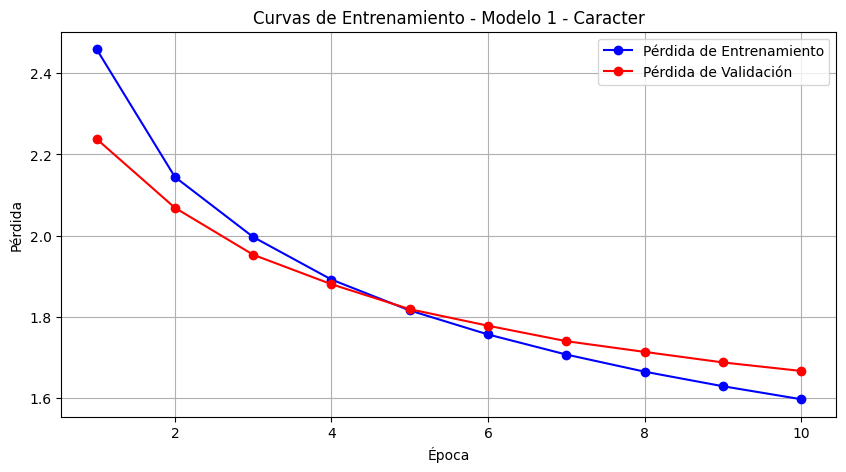

In [ ]:
graficar(history_1_char, "Modelo 1 - Caracter")

La gráfica de este modelo muestra que no existe como tal un overfitting ya que tanto como la gráfica de entrenamiento como de prueba tienden a bajar, con una diferencia en el ratio de descenso.

### Modelo 1: Gráfica de entrenamiento de palabras.

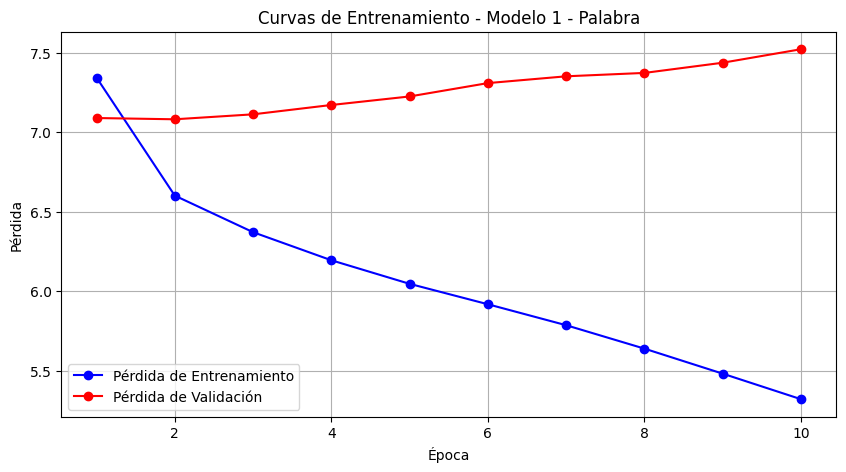

In [ ]:
graficar(history_1_word, "Modelo 1 - Palabra")

Para el modelo 1 a nivel palabra se muestra un claro ejemplo de overfitting ya que como se muestra la pérdida tiende a la baja mientras que la de validación sube. La diferencia es demasiado evidente.  

## Modelo 2: Gráfica de entrenamiento de caracteres.

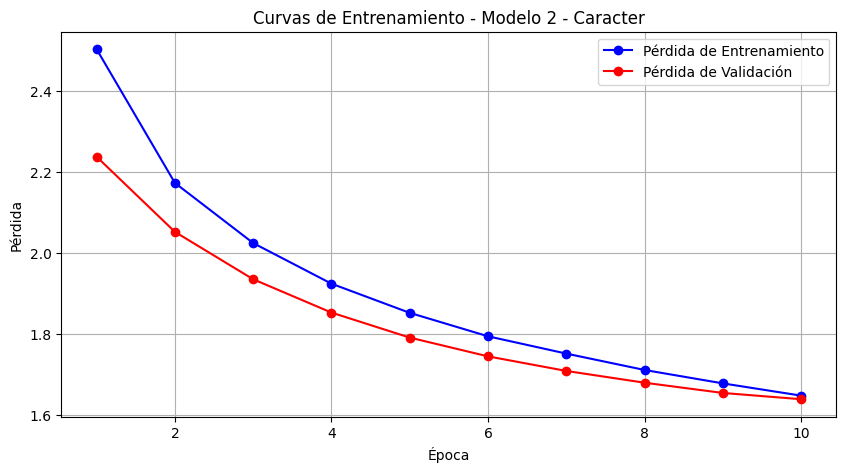

In [ ]:
graficar(history_2_char, "Modelo 2 - Caracter")

Para este caso, ambas gráficas tienden a la baja casi de forma paralela, lo que hace que el modelo sea estable y no exista el overfitting.

## Modelo 2: Gráfica de entrenamiento de palabras.

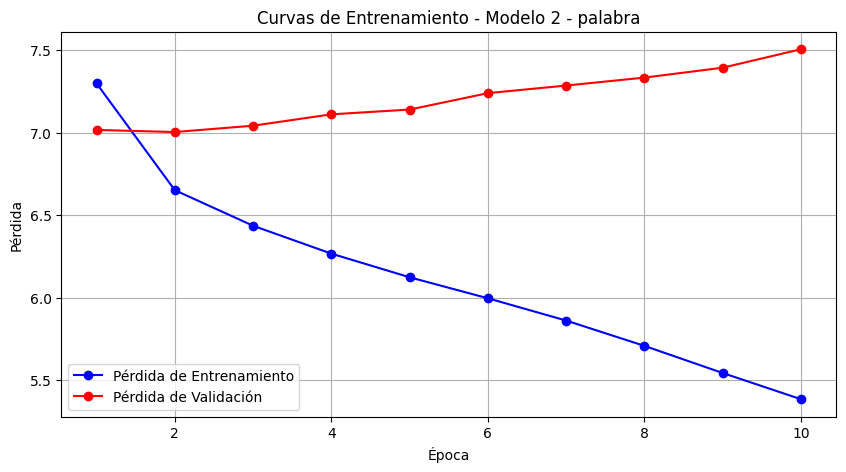

In [ ]:
graficar(history_2_word, "Modelo 2 - palabra")

Al igual que el modelo 1 al nivel palabra, se muestra un claro overfitting en el modelo, ya que mientras la pérdida de entrenamiento baja de manera constante, la gráfica de pérdida va en aumento, con una gran diferencia entre ambas líneas.

## Modelo 3: Gráfica de entrenamiento de caracteres.


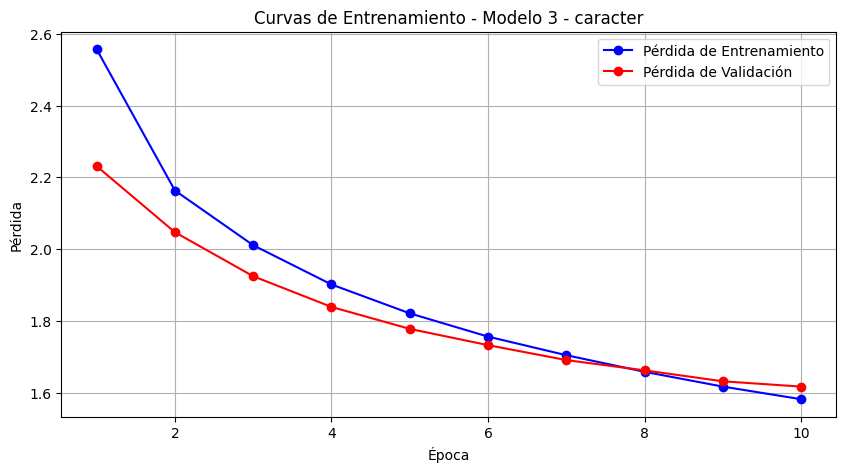

In [ ]:
graficar(history_3_char, "Modelo 3 - caracter")

Al igual que el modelo 2 a nivel caracter no existe sobreajuste en este modelo ya que ambas gráficas bajan de manera conjunta.

## Modelo 3: Gráfica de entrenamiento de palabras.


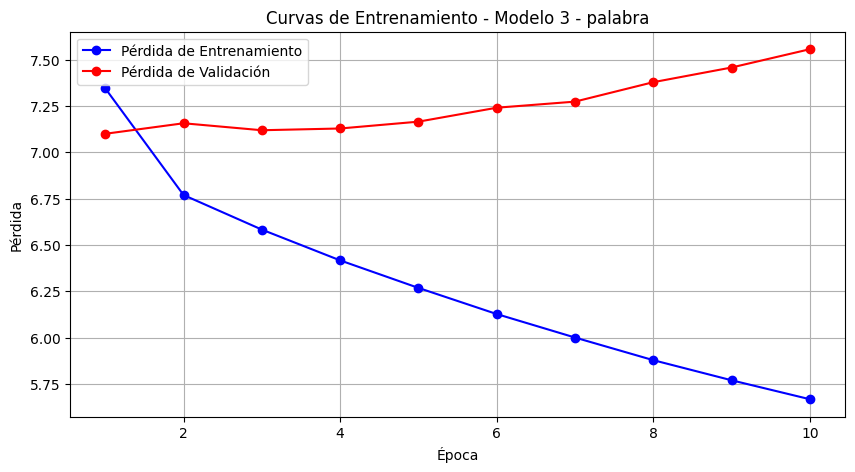

In [ ]:
graficar(history_3_word, "Modelo 3 - palabra")

El modelo falla al momento de realizar la generalización ya que ambas curvas difieren, lo que implica que memoriza los datos entrenados como se muestra en las anteriores gráficas de los modelos de palabras.

## Modelo 4: Gráfica de entrenamiento de caracteres.


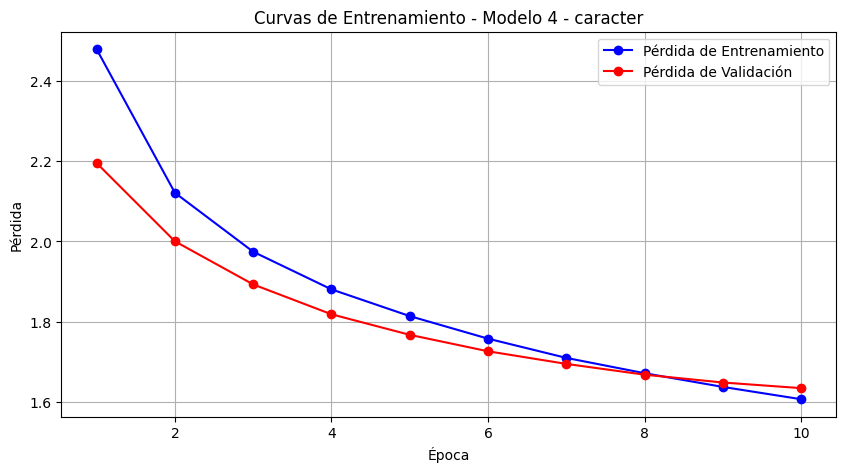

In [ ]:
graficar(history_4_char, "Modelo 4 - caracter")

Como en los anteriores modelos de caracteres, tampoco se muestra un overfitting.

## Modelo 4: Gráfica de entrenamiento de palabras.


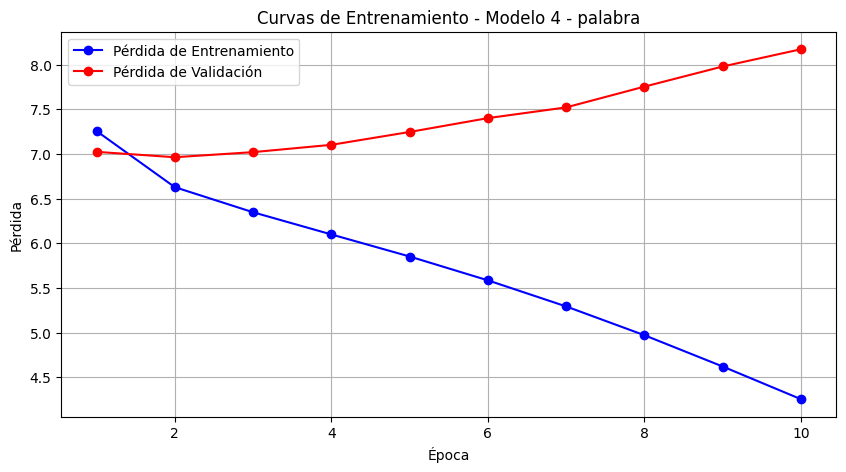

In [ ]:
graficar(history_4_word, "Modelo 4 - palabra")

Las curvas de igual manera difieren como en los modelos de palabras, por lo que existe un gran desbalance en las predicciones, lo que hace que exista el overfitting.

# 3.3 Generación cualitativa de texto

Para la generación del texto, los algoritmos a utilizar son Greedy y multinomial.

El muestreo de greedy es un algoritmo de decisión determinista, esto significa que en cada paso el modelo calcula la probabilidad de cada posible palabra o caracter en el vocabulario. Este simplemente elige la palabra única que tiene la probabilidad máx alta. No hay aleatoriedad en este algoritmo. Esto hace que el texto de salida sea repetitivo.
Por ejemplo, si la semilla es "la música clásica es..." el modelo predecirá la siguiente palabra ante estas palabras: ["muy": 45%, "extremadamente": 20%, "a": 10%, "la": 5%, "arte": 5%, "otras palabras": menos del 15%]. Ante estas entradas, este algoritmo predecirá la palabra "muy" porque es la más común en probabilidades. La siguiente palabra predicha se realiza de la misma manera.

Por otra parte, el muestreo multinomial es un algoritmo aleatorio. Este método usa la probabilidad basándose en las veces que aparece una palabra, con la diferencia de que por ejemplo, una palabra con un 45% de probabilidad será seleccionada el 45% de las veces, una con 20% será seleccionada el 20% de las veces, y así sucesivamente.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import os

# Generar caracteres
def generar_texto_char(model, seed_prompt, n_chars_to_generate, seq_len, char_to_int_map, int_to_char_map, sampling_mode='multinomial', temperature=1.0):

    generated_output = seed_prompt

    input_sequence_int = [char_to_int_map[c] for c in seed_prompt.lower() if c in char_to_int_map]
    current_sequence = pad_sequences([input_sequence_int], maxlen=seq_len, truncating='pre', padding='pre')

    for _ in range(n_chars_to_generate):

        preds = model.predict(current_sequence, verbose=0)[0]

        if sampling_mode == 'greedy':
            next_index = np.argmax(preds)
        else:
            # Evitar dividir por cero si la temperatura es muy baja
            if temperature <= 0:
                temperature = 0.01

            logits = np.log(preds + 1e-9) / temperature
            next_index = tf.random.categorical(logits[np.newaxis, :], num_samples=1).numpy().flatten()[0]

        next_char = int_to_char_map.get(next_index, '?')

        generated_output += next_char

        current_sequence = np.append(current_sequence[0][1:], [next_index])
        current_sequence = np.reshape(current_sequence, (1, seq_len))

    return generated_output

# Generar palabras
def generar_texto_word(model, seed_prompt, n_words_to_generate, seq_len, keras_tokenizer, sampling_mode='multinomial', temperature=1.0):

    generated_output = seed_prompt

    input_sequence_int = keras_tokenizer.texts_to_sequences([seed_prompt.lower()])[0]
    current_sequence = pad_sequences([input_sequence_int], maxlen=seq_len, truncating='pre', padding='pre')

    for _ in range(n_words_to_generate):

        preds = model.predict(current_sequence, verbose=0)[0]

        if sampling_mode == 'greedy':
            next_index = np.argmax(preds)
        else:
            if temperature <= 0:
                temperature = 0.01

            logits = np.log(preds + 1e-9) / temperature
            next_index = tf.random.categorical(logits[np.newaxis, :], num_samples=1).numpy().flatten()[0]

        next_word = keras_tokenizer.index_word.get(next_index, '?')

        generated_output += " " + next_word

        current_sequence = np.append(current_sequence[0][1:], [next_index])
        current_sequence = np.reshape(current_sequence, (1, seq_len))

    return generated_output

In [ ]:
seed_prompt_char = "the art of music is one of the most interesting"
print(f"Prompt Semilla: '{seed_prompt_char}'\n")

seed_prompt_word = "the great masters of the modern school of music are"
print(f"Prompt Semilla: '{seed_prompt_word}'\n")

Prompt Semilla: 'the art of music is one of the most interesting'

Prompt Semilla: 'the great masters of the modern school of music are'



### Modelo 1

In [ ]:

print("\n" + "="*50)
print("--- Generación de Texto (Modelo 1 - Carácter) ---")

print("--- Muestreo Greedy ---")
generated_text_greedy = generar_texto_char(
    model_1_char,
    seed_prompt_char,
    200,
    longitud_secuencia,
    char_a_int,
    int_a_char,
    sampling_mode='greedy'
)
print(generated_text_greedy)

print("\n--- Muestreo Multinomial ---")
generated_text_temp = generar_texto_char(
    model_1_char,
    seed_prompt_char,
    200,
    longitud_secuencia,
    char_a_int,
    int_a_char,
    sampling_mode='multinomial',
    temperature=1.0
)
print(generated_text_temp)



print("\n" + "="*50)
print("--- Generación de Texto (Modelo 1 - Palabra) ---")



print("--- Muestreo Greedy --")
generated_text_word_greedy = generar_texto_word(
    model_1_word,
    seed_prompt_word,
    30,
    secuencia_palabra,
    tokenizer,
    sampling_mode='greedy'
)
print(generated_text_word_greedy)

print("\n--- Muestreo Multinomial ---")
generated_text_word_temp = generar_texto_word(
    model_1_word,
    seed_prompt_word,
    30,
    secuencia_palabra,
    tokenizer,
    sampling_mode='multinomial',
    temperature=1.0
)
print(generated_text_word_temp)


--- Generación de Texto (Modelo 1 - Carácter) ---
--- Muestreo Greedy ---
the art of music is one of the most interesting the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the 

--- Muestreo Multinomial ---
the art of music is one of the most interesting sonciest of theabons andthreesects ofthe litwenthithameration. the callt the crodded inteurstyom', and it is melybord must and prod.sever pase, the princmally senth, complibor-not colestamoniquenery,

--- Generación de Texto (Modelo 1 - Palabra) ---
--- Muestreo Greedy --
the great masters of the modern school of music are the first of the first of the first and the first of the first of the first and the first of the first of the first and the first of

--- Muestreo Multinomial ---
the great masters of the modern school of music are have opened all this there hollaender from the manuscript h

### Modelo 2

In [ ]:
print("\n" + "="*50)
print("--- Generación de Texto (Modelo 2 - Carácter) ---")

print(f"Prompt Semilla: '{seed_prompt_char}'\n")

print("--- Muestreo Greedy ---")
generated_text_greedy = generar_texto_char(
    model_2_char,
    seed_prompt_char,
    200,
    longitud_secuencia,
    char_a_int,
    int_a_char,
    sampling_mode='greedy'
)
print(generated_text_greedy)

print("\n--- Muestreo Multinomial ---")
generated_text_temp = generar_texto_char(
    model_2_char,
    seed_prompt_char,
    200,
    longitud_secuencia,
    char_a_int,
    int_a_char,
    sampling_mode='multinomial',
    temperature=1.0
)
print(generated_text_temp)



print("\n" + "="*50)
print("--- Generación de Texto (Modelo 2 - Palabra) ---")

print(f"Prompt Semilla: '{seed_prompt_word}'\n")

print("--- Muestreo Greedy --")
generated_text_word_greedy = generar_texto_word(
    model_2_word,
    seed_prompt_word,
    30,
    secuencia_palabra,
    tokenizer,
    sampling_mode='greedy'
)
print(generated_text_word_greedy)

print("\n--- Muestreo Multinomial ---")
generated_text_word_temp = generar_texto_word(
    model_2_word,
    seed_prompt_word,
    30,
    secuencia_palabra,
    tokenizer,
    sampling_mode='multinomial',
    temperature=1.0
)
print(generated_text_word_temp)


--- Generación de Texto (Modelo 2 - Carácter) ---
Prompt Semilla: 'the art of music is one of the most interesting'

--- Muestreo Greedy ---
the art of music is one of the most interesting the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the 

--- Muestreo Multinomial ---
the art of music is one of the most interesting didede_ upon the _pimplines, the piractations instruments posmite (inh they those twansposed. goms it lastollowing cinger instruments, their place of inthere enadie is ouve, in the ammony, was not th

--- Generación de Texto (Modelo 2 - Palabra) ---
Prompt Semilla: 'the great masters of the modern school of music are'

--- Muestreo Greedy --
the great masters of the modern school of music are a art of the art of the art of the art of the art of the art of the art of the art of the art of the art of

--- Muestreo Multinomial --

### Modelo 3

In [ ]:
print("\n" + "="*50)
print("--- Generación de Texto (Modelo 3 - Carácter) ---")

print(f"Prompt Semilla: '{seed_prompt_char}'\n")

print("--- Muestreo Greedy ---")
generated_text_greedy = generar_texto_char(
    model_3_char,
    seed_prompt_char,
    200,
    longitud_secuencia,
    char_a_int,
    int_a_char,
    sampling_mode='greedy'
)
print(generated_text_greedy)

print("\n--- Muestreo Multinomial ---")
generated_text_temp = generar_texto_char(
    model_3_char,
    seed_prompt_char,
    200,
    longitud_secuencia,
    char_a_int,
    int_a_char,
    sampling_mode='multinomial',
    temperature=1.0
)
print(generated_text_temp)



print("\n" + "="*50)
print("--- Generación de Texto (Modelo 3 - Palabra) ---")

print(f"Prompt Semilla: '{seed_prompt_word}'\n")

print("--- Muestreo Greedy --")
generated_text_word_greedy = generar_texto_word(
    model_3_word,
    seed_prompt_word,
    30,
    secuencia_palabra,
    tokenizer,
    sampling_mode='greedy'
)
print(generated_text_word_greedy)

print("\n--- Muestreo Multinomial ---")
generated_text_word_temp = generar_texto_word(
    model_3_word,
    seed_prompt_word,
    30,
    secuencia_palabra,
    tokenizer,
    sampling_mode='multinomial',
    temperature=1.0
)
print(generated_text_word_temp)


--- Generación de Texto (Modelo 3 - Carácter) ---
Prompt Semilla: 'the art of music is one of the most interesting'

--- Muestreo Greedy ---
the art of music is one of the most interesting the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the strings of the 

--- Muestreo Multinomial ---
the art of music is one of the most interestingsank them the most songmitic.alowic. from and his any formerant of these no frind with the anable centural asthere was greater four this wad thenamplations aroun immort waling itarityxipefaancing rest

--- Generación de Texto (Modelo 3 - Palabra) ---
Prompt Semilla: 'the great masters of the modern school of music are'

--- Muestreo Greedy --
the great masters of the modern school of music are the art of the art of the art of the art of the art of the art of the art of the art of the art of the art of

--- Muestreo Multinomial 

### Modelo 4.

In [ ]:
print("\n" + "="*50)
print("--- Generación de Texto (Modelo 4 - Carácter) ---")

print(f"Prompt Semilla: '{seed_prompt_char}'\n")

print("--- Muestreo Greedy ---")
generated_text_greedy = generar_texto_char(
    model_4_char,
    seed_prompt_char,
    200,
    longitud_secuencia,
    char_a_int,
    int_a_char,
    sampling_mode='greedy'
)
print(generated_text_greedy)

print("\n--- Muestreo Multinomial ---")
generated_text_temp = generar_texto_char(
    model_4_char,
    seed_prompt_char,
    200,
    longitud_secuencia,
    char_a_int,
    int_a_char,
    sampling_mode='multinomial',
    temperature=1.0
)
print(generated_text_temp)



print("\n" + "="*50)
print("--- Generación de Texto (Modelo 4 - Palabra) ---")

print(f"Prompt Semilla: '{seed_prompt_word}'\n")

print("--- Muestreo Greedy --")
generated_text_word_greedy = generar_texto_word(
    model_4_word,
    seed_prompt_word,
    30,
    secuencia_palabra,
    tokenizer,
    sampling_mode='greedy'
)
print(generated_text_word_greedy)

print("\n--- Muestreo Multinomial ---")
generated_text_word_temp = generar_texto_word(
    model_4_word,
    seed_prompt_word,
    30,
    secuencia_palabra,
    tokenizer,
    sampling_mode='multinomial',
    temperature=1.0
)
print(generated_text_word_temp)


--- Generación de Texto (Modelo 4 - Carácter) ---
Prompt Semilla: 'the art of music is one of the most interesting'

--- Muestreo Greedy ---
the art of music is one of the most interesting the songs of the song of the strings of the singers the singers the strings of the singers of the propers of the proportions of the singers the song of the composer of the song of the song of the con

--- Muestreo Multinomial ---
the art of music is one of the most interesting moded, adsectrije., " the ervercepushions. the livies into the, more lableliation; is to the conssing. finr (ensmanded') of a praiely. had chapaation of the dixtrafter or well and conrestion to headm

--- Generación de Texto (Modelo 4 - Palabra) ---
Prompt Semilla: 'the great masters of the modern school of music are'

--- Muestreo Greedy --
the great masters of the modern school of music are alsobeen know the great melodic fire and the cathedral of st mark's to be put in england and died in connection to us in the crusaders m

En ningúno de los 8 casos produce un texto coherente o con algún sentido. A nivel caracter, el muestreo multinomial pareciese que produce texto coherente, sin embargo queda aclarar que en su mayoría son inventadas mientras que le muestreo Greedy se cicla con respecto a la repetición. Por otra parte, a nivel palabra, el muestreo multinomial genera una bolsa de palabras y las concatena entre si, sin ningún sentido gramatical o incluso semántico.

La mayoría de los modelos (exceptuando quiza el modelo 4) caen siempre en una repetición simple con el muestreo Greedy. En el caso del muestreo multinomial, es bueno evitando los bucles de repetición pero genera texto muy variado, sin sentido alguno.

A nivel caracter, los modelos si presentan nuevas palabras inventadas pero sin coherencia en la mayoría de los mismos. A nivel palabra los modelos no inventan nuevas. Usan palabras reales aunque las coloquen sin sentido.

Con respecto a si respetan o no el corpus, a nivel caracter, las palabras inventadas se leen como palabras en inglés o latín lo que puede demostrar que el modelo aprendió las reglas básicas de ortografía del corpus. Por otra parte, para el nivel de palabras, aunque las oraciones no son correctas, el tipo de palabras que eligen los modelos pertenece al texto original del corpus. Los modelos capturaron lo reelevante del vocabulario.

# Discusión y conclusiones

A nivel caracter, el mejor modelo fue Modelo 3 (Stacked LSTM) debido a que este fue el modelo que alcanzó la menor perplejidad (aproximadamente 4.9827), lo que sugiere que tiene menor confusión y es más preciso al predecir el siguiente caracter. El hecho de que haya sido mejor modelo puede ser debido a el contexto anterior que maneja en las capas ya que la primera capa LSTM probablemente aprendió patrones básicos o de bajo nivel y la segunda capa utilizó estos patrones para comprender dependencias más largas.

A nivel palabra, no hubo alguna que funcionara de manera tan correcta, sin embargo el mejor modelo fue el 2 (LSTM + Dropout) el cual logró una perplejidad de 2367.4313 y es por poco superior al modelo 1. Todos los modelos de palabras muestran un sobreajuste por lo que sugiere que para el modelo esta tarea es demasiado compleja.

Con respecto al dropout a nivel caracter fue más efectivo. El modelo 1 mostró un ligero sobreajuste mientras que el modelo 2 eliminó (esto se observa en la diferencia entre la pérdida de test y validación). A nivel palabra esto no funcionó de manera correcta. Los dos modelos en este caso mostraron un sobreajuste grande.

El modelo 4 bidireccional solo aumentó el costo y empeoró de gran manera los resultados. A nivel caracter la perplejidad no mejoró y a nivel palabra resultó en la peor perplejidad. Al ser más complejo el modelo solo memorizó los datos de entrenamiento aun más rapido pero falló en la generalización.

Con respecto al modelo 3 (apilado) a nivel caracter obtuvo la perplejidad más baja de todos los modelos, sin embargo con respecto a las palabras, la perplejidad fue peor que la de los primeros modelos, por lo que a nivel caracter logró capturar dependencias más largas.

En cuanto a las limitaciones del dataset, se tomaron únicamene un conjunto reducido de secuencias de entrenamiento los cuales son insuficientes para que los modelos aprendan el vocabulario de todas las palabras.

En general, los mejores modelos a nivel caracter con estas limitaciones demostraron funcionar de manera mas estable y lograron una perplejidad más baja.